# Preamble

## Imports & Path

In [1]:
%cd ..

/home/aru/Work/shome2023notebook


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, fisher_exact
from scipy.stats.contingency import association

In [3]:
sns.set_theme(
    context="talk",
    palette="colorblind",
    style="whitegrid",
)

## Data Loading & Prep


In [4]:
data = pd.read_csv("data/shome2023notebook/annotations.csv")
data.head()

,notebook,stmt,source,CALL,CGH,CKG,EC,Intent,Stage,Notes,Type
0,data/assert_notebooks/lepmik/meta-reinforcemen...,np.unique(env._s_hist[:-1][np.diff(env._s_hist...,GH,-1,-2.0,NaN,NaN,EXP,EVAL,RL context. Diagnostic to identify which state...,COMPUTE
1,data/assert_notebooks/dhuynh95/cryptotree/nbs/...,"(comparator.weight.data, comparator.bias.data)",GH,117,-2.0,NaN,NaN,EXP,EVAL,Check learned weights and bias of model.,INSPECT
2,data/assert_notebooks/nikohou/LoadLanguageMode...,assert dim % 2 == 0,GH,992,-2.0,NaN,NaN,VAL,MODEL,Defined inside `__init__` method of a neural n...,EQ
3,data/assert_notebooks/EricCousineau-TRI/repro/...,assert activated.ndim > 1,GH,1021,-2.0,NaN,NaN,VAL,MODEL,"Ensure activation tensor is a batch (2D), not ...",SHAPE
4,data/assert_notebooks/H-E-L-P/XID_plus/docs/bu...,"plt.plot(test_x, test_y, 'ro', alpha=0.5)",GH,614,-2.0,NaN,NaN,EXP,EVAL,Visually inspect actual vs. predictions of the...,INSPECT


## Helper Functions

In [5]:
def annot_count_with_percent(ax, orient="v") -> None:
    """Annotate each bar with count and percentage relative to hue size."""
    get_val = (lambda p: p.get_width()) if orient == "h" else (lambda p: p.get_height())
    for container in ax.containers:
        total = sum(get_val(p) for p in container)
        labels = [
            f"{int(get_val(p))} ({100 * get_val(p) / total:.1f}%)"
            for p in container
        ]
        ax.bar_label(container, labels=labels, fontsize=10.0)

In [6]:
def counts(data, col):
    counts = data[col].value_counts()
    pct = data[col].value_counts(normalize=True).mul(100).round(1)
    return pd.concat([counts, pct], axis=1, keys=["count", "pct"])

# Function intent of validation statements (Dimension A)

## Top-level intent split (VAL vs EXP vs DOC)

In [7]:
pd.concat({
    "Total": counts(data, "Intent"),
    "GH": counts(data[data["source"] == "GH"], "Intent"),
    "KG": counts(data[data["source"] == "KG"], "Intent"),
})

count   pct
      Intent             
Total EXP       692  84.9
      VAL       123  15.1
GH    EXP       263  68.8
      VAL       119  31.2
KG    EXP       429  99.1
      VAL         4   0.9

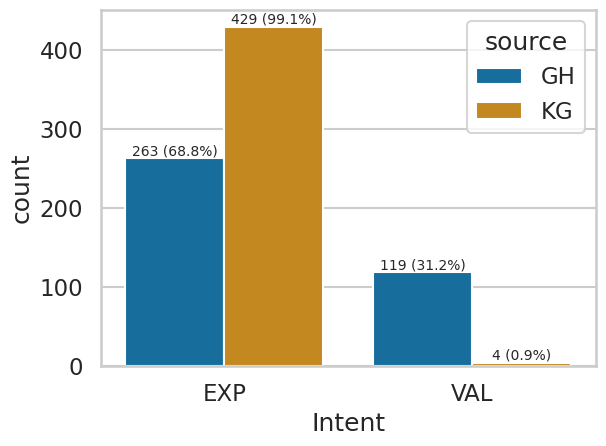

In [8]:
ax = sns.countplot(
    data=data,
    x='Intent',
    order=data["Intent"].value_counts().index,
    hue='source'
)
annot_count_with_percent(ax)
ax.get_figure().tight_layout()
ax.get_figure().savefig("report/distribution-intent.pdf")

Are the two populations siginificantly different from one another? We apply Fisher Exact test since the observed sample size of VAL in KG is small (<5).

In [9]:
observed = pd.crosstab(data["source"], data["Intent"])
res = fisher_exact(observed)
print(f"p: {res.pvalue} cramer's V: {association(observed)}")

p: 8.898461849158505e-39 cramer's V: 0.4213859836358953


$pvalue < 0.001$ so we reject $H_0$. This means that there is a significant difference between the Intent of the statements from GH and KG.

## EXP breakdown

In [10]:
d = data[data["Intent"] == "EXP"]

In [11]:
pd.concat({
    "Total": counts(d, "Type"),
    "GH": counts(d[d["source"] == "GH"], "Type"),
    "KG": counts(d[d["source"] == "KG"], "Type"),
})

count   pct
      Type                
Total INSPECT    303  43.8
      COMPUTE    185  26.7
      STRUCT     126  18.2
      STATS       78  11.3
GH    INSPECT    121  46.0
      COMPUTE     82  31.2
      STRUCT      40  15.2
      STATS       20   7.6
KG    INSPECT    182  42.4
      COMPUTE    103  24.0
      STRUCT      86  20.0
      STATS       58  13.5

Are the populations significantly different? We apply $X^2$ test since the sample size is large.

In [12]:
observed = pd.crosstab(d["source"], d["Type"])
res = chi2_contingency(observed)
print(f"p: {res.pvalue} cramers v: {association(observed)}")

p: 0.013038590514346938 cramers v: 0.12475242426582903


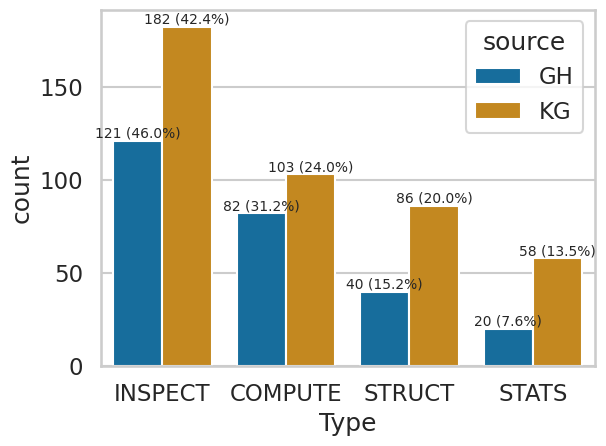

In [13]:
ax = sns.countplot(
    data=d,
    x="Type",
    order=d["Type"].value_counts().index,
    hue="source",
)
annot_count_with_percent(ax)
ax.get_figure().tight_layout()
ax.get_figure().savefig("report/distribution-intent-exp.pdf")

## VAL breakdown
GH focused since KG only contains 4 assertions.

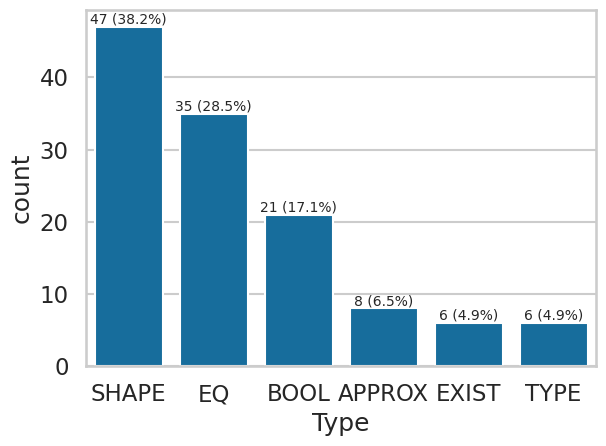

In [14]:
d = data[data["Intent"] == "VAL"]
ax = sns.countplot(
    data=d,
    x="Type",
    order=d["Type"].value_counts().index,
)
annot_count_with_percent(ax)
ax.get_figure().tight_layout()

# ML pipeline stage distribution (Dimension B)

In [15]:
pd.concat({
    "Total": counts(data, "Stage"),
    "GH": counts(data[data["source"] == "GH"], "Stage"),
    "KG": counts(data[data["source"] == "KG"], "Stage"),
})

count   pct
      Stage             
Total PREP     329  40.4
      EVAL     171  21.0
      DATA     100  12.3
      FEAT     100  12.3
      TRAIN     71   8.7
      MODEL     42   5.2
      UNC        2   0.2
GH    EVAL      94  24.6
      PREP      76  19.9
      DATA      71  18.6
      TRAIN     50  13.1
      FEAT      49  12.8
      MODEL     40  10.5
      UNC        2   0.5
KG    PREP     253  58.4
      EVAL      77  17.8
      FEAT      51  11.8
      DATA      29   6.7
      TRAIN     21   4.8
      MODEL      2   0.5

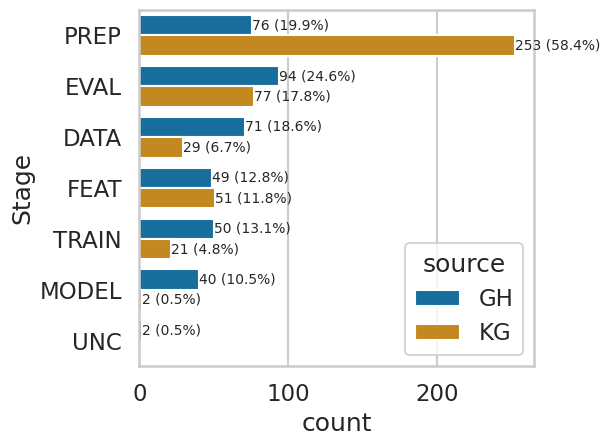

In [16]:
ax = sns.countplot(
    data=data,
    y="Stage",
    hue="source",
    order=data["Stage"].value_counts().index,
)
annot_count_with_percent(ax, orient="h")
ax.get_figure().tight_layout()